In [1]:
import numpy as np
import pint

from jablonski import (
    Simulator,
    SingletState,
    SpectroscopicSystem,
    TripletState,
    initial,
)
from jablonski.simulation import (
    delta_excitation,
    piecewise,
    pulse_excitation,
    spectral_time_resolved_emission,
)
from jablonski.transitions import (
    Absorption,
    Fluorescence,
    IntersystemCrossing,
    Phosphorescence,
)

u = pint.get_application_registry()


class Model(SpectroscopicSystem):
    # Define states with energies, mid is a triplet state
    low: SingletState = initial(0 * u.eV, "singlet", default=100)
    mid: TripletState = initial(2 * u.eV, "triplet", default=0)
    high: SingletState = initial(3 * u.eV, "singlet", default=0)

    # Define absorptions and emissions
    absorption_1 = Absorption(ground=low, excited=high, rate=1e-15 * u.cm**2)
    emission_1 = Phosphorescence(ground=low, excited=mid, rate=2e8 / u.s)
    emission_2 = IntersystemCrossing(source=high, target=mid, rate=0.5e8 / u.s)
    emission_3 = Fluorescence(ground=low, excited=high, rate=1e8 / u.s)


sim = Simulator(Model)

C:\Users\olive\dyscolab\u2602\poincare\src\poincare\simulator.py:181: FutureWarning: save at dimensionality None doesn't match (explicit or implicit) dimensionality of Independent [time]. Unit consistency in save_at will be enforced with an error in future versions.
  warn(


<Axes: xlabel='time'>

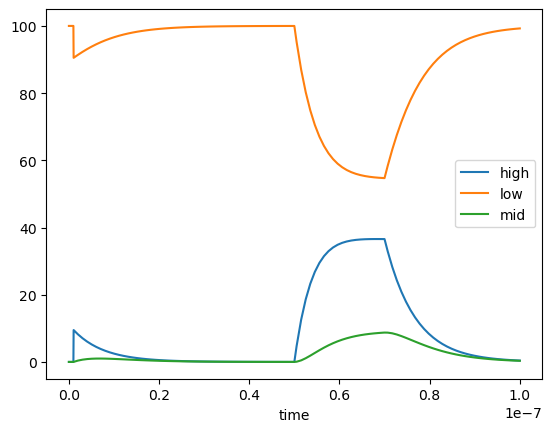

In [2]:
# Picewise simulation with a delta excitation at t = 0 and a pulse between t = 5 and t = 7
delta = delta_excitation(
    Model.absorption_1, start=0.1e-8 * u.s, area=1e14 / u.cm**2
)  # delta excitiation
pulse = pulse_excitation(
    Model.absorption_1, start=5e-8, width=2e-8, height=1e23 / (u.cm**2 * u.s)
)  # delta excitiation
result_1 = piecewise(sim, events=delta | pulse, save_at=np.linspace(0, 10e-8, 100))
result_1.to_dataframe().plot()

In [3]:
result_1

<xarray.Dataset> Size: 3kB
Dimensions:  (time: 104)
Coordinates:
  * time     (time) float64 832B 0.0 1e-09 1.01e-09 ... 9.899e-08 1e-07
Data variables:
    high     (time) float64 832B 0.0 0.0 1.998 9.481 ... 0.5505 0.4733 0.4069
    low      (time) float64 832B 100.0 100.0 98.0 90.51 ... 99.0 99.14 99.26
    mid      (time) float64 832B 0.0 0.0 0.0005062 ... 0.4475 0.3888 0.3376

line_emission_1: 2 electron_volt
line_emission_3: 3 electron_volt


C:\Users\olive\dyscolab\u2602\poincare\src\poincare\simulator.py:181: FutureWarning: save at dimensionality None doesn't match (explicit or implicit) dimensionality of Independent [time]. Unit consistency in save_at will be enforced with an error in future versions.
  warn(


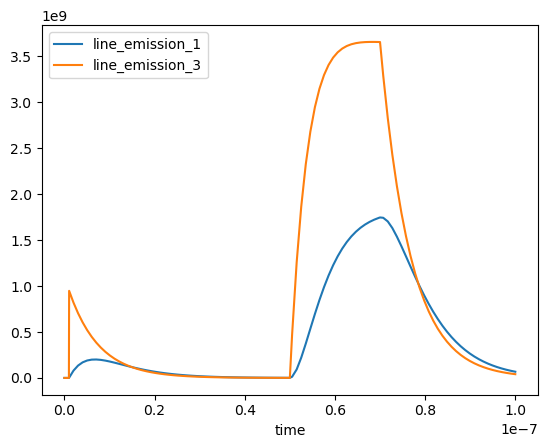

In [4]:
# spectral time resolved emission for same excitation
result_2 = spectral_time_resolved_emission(
    Model, excitation=delta | pulse, save_at=np.linspace(0, 10e-8, 100)
)
result_2.pint.dequantify().to_dataframe().plot()

# We can see each lines energy in the Datasets attributes
for line, energy in result_2.attrs.items():
    print(f"{line}: {energy}")

C:\Users\olive\dyscolab\u2602\poincare\src\poincare\simulator.py:181: FutureWarning: save at dimensionality None doesn't match (explicit or implicit) dimensionality of Independent [time]. Unit consistency in save_at will be enforced with an error in future versions.
  warn(


<Axes: xlabel='time'>

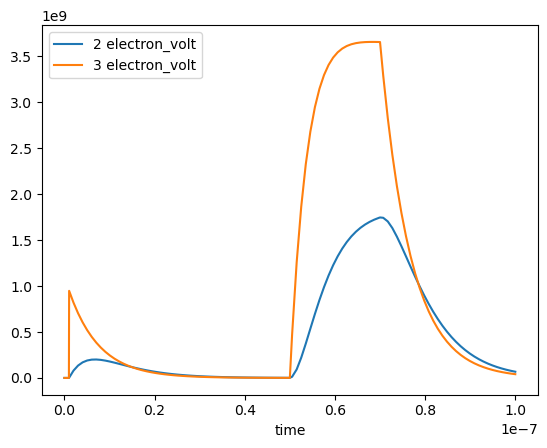

In [5]:
# join_by_energy groups lines of the same energy and outputs energy instead of name
result_2 = spectral_time_resolved_emission(
    Model,
    excitation=delta | pulse,
    save_at=np.linspace(0, 10e-8, 100),
    join_by_energy=True,
)
result_2.pint.dequantify().to_dataframe().plot()